In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import EXP_neuro_fuzzy_toolbox as nft

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.7,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [5]:
Y.mean(), Y.std()

(np.float64(0.35986148242232785), np.float64(2.140979400890615))

In [6]:
Y_test.mean(), Y_test.std()

(np.float64(0.3105455269731688), np.float64(1.8614787773152441))

In [8]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [9]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=torch.float32), 
        torch.tensor(Y, dtype=torch.float32)
        ), 
    batch_size = 32, 
    shuffle = True)

In [10]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

## Model & Training

In [12]:
model = nft.h_ANFIS(
    input_size = 2,
    num_mfs = 6,
    outputs = 1,
    rule_reduced = False,
    dtype = x_train.dtype
)

In [26]:
model.init_premises(x_train)

In [27]:
model.get_premises_structure()

x0             x1          
     a    b    c    a    b    c
0  0.2  4.0 -1.0  0.2  4.0 -1.0
1  0.2  4.0 -0.6  0.2  4.0 -0.6
2  0.2  4.0 -0.2  0.2  4.0 -0.2
3  0.2  4.0  0.2  0.2  4.0  0.2
4  0.2  4.0  0.6  0.2  4.0  0.6
5  0.2  4.0  1.0  0.2  4.0  1.0

In [28]:
model.get_premises()

tensor([[[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]],

        [[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]]])

In [29]:
model.get_premises_as_parameters_list()

[Parameter containing:
 tensor([[[ 0.2000,  4.0000, -1.0000],
          [ 0.2000,  4.0000, -0.6000],
          [ 0.2000,  4.0000, -0.2000],
          [ 0.2000,  4.0000,  0.2000],
          [ 0.2000,  4.0000,  0.6000],
          [ 0.2000,  4.0000,  1.0000]],
 
         [[ 0.2000,  4.0000, -1.0000],
          [ 0.2000,  4.0000, -0.6000],
          [ 0.2000,  4.0000, -0.2000],
          [ 0.2000,  4.0000,  0.2000],
          [ 0.2000,  4.0000,  0.6000],
          [ 0.2000,  4.0000,  1.0000]]], requires_grad=True)]

In [17]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = nft.EarlyStopping(patience=30)

trainer = nft.Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [18]:
trainer(model, train_loader, verbose=True)

Epoch:   1/500 - loss: 0.503255 - validation loss: 0.784371
Epoch:   2/500 - loss: 0.500798 - validation loss: 0.784856
Epoch:   3/500 - loss: 0.498673 - validation loss: 0.782989
Epoch:   4/500 - loss: 0.496766 - validation loss: 0.781084
Epoch:   5/500 - loss: 0.494923 - validation loss: 0.779519
Epoch:   6/500 - loss: 0.492904 - validation loss: 0.778482
Epoch:   7/500 - loss: 0.491041 - validation loss: 0.776293
Epoch:   8/500 - loss: 0.489323 - validation loss: 0.775353
Epoch:   9/500 - loss: 0.487484 - validation loss: 0.773195
Epoch:  10/500 - loss: 0.485598 - validation loss: 0.771902
Epoch:  11/500 - loss: 0.484241 - validation loss: 0.770503
Epoch:  12/500 - loss: 0.482419 - validation loss: 0.768709
Epoch:  13/500 - loss: 0.480792 - validation loss: 0.765895
Epoch:  14/500 - loss: 0.479414 - validation loss: 0.764797
Epoch:  15/500 - loss: 0.478014 - validation loss: 0.764125
Epoch:  16/500 - loss: 0.476385 - validation loss: 0.761567
Epoch:  17/500 - loss: 0.475127 - valida

In [20]:
model.get_premises_structure()

x0                            x1                    
          a         b         c         a         b         c
0  0.188576  3.999273 -1.010095  0.228047  4.024335 -0.958047
1  0.200835  4.002566 -0.575909  0.219259  3.863109 -0.561855
2  0.235728  3.962746 -0.190845  0.227124  4.043515 -0.190561
3  0.228186  3.972636  0.183926  0.238337  3.934767  0.184657
4  0.228411  3.977984  0.534581  0.243157  3.908396  0.596699
5  0.230830  3.977241  0.968466  0.259248  3.938991  0.946480

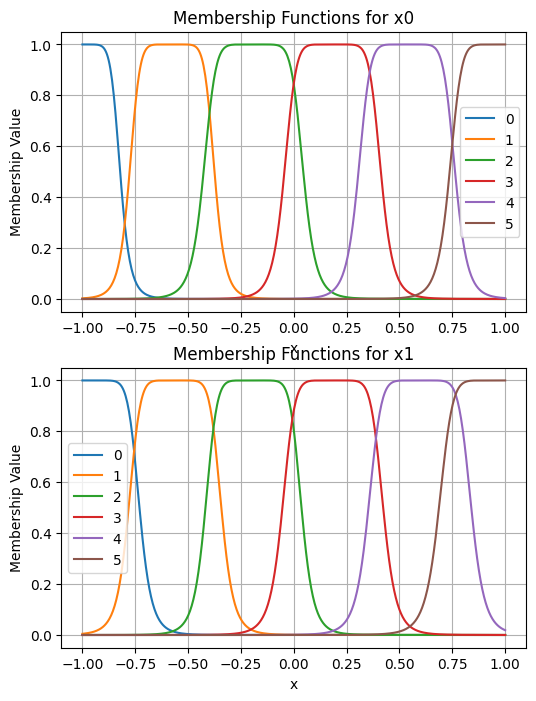

In [21]:
model.plot_premises(group_by_dim=True)

In [23]:
model.get_rules_structure()

premises                                                    \
               x0                            x1                       
                a         b         c         a         b         c   
rule 1   0.188576  3.999273 -1.010095  0.228047  4.024335 -0.958047   
rule 2   0.188576  3.999273 -1.010095  0.219259  3.863109 -0.561855   
rule 3   0.188576  3.999273 -1.010095  0.227124  4.043515 -0.190561   
rule 4   0.188576  3.999273 -1.010095  0.238337  3.934767  0.184657   
rule 5   0.188576  3.999273 -1.010095  0.243157  3.908396  0.596699   
rule 6   0.188576  3.999273 -1.010095  0.259248  3.938991  0.946480   
rule 7   0.200835  4.002566 -0.575909  0.228047  4.024335 -0.958047   
rule 8   0.200835  4.002566 -0.575909  0.219259  3.863109 -0.561855   
rule 9   0.200835  4.002566 -0.575909  0.227124  4.043515 -0.190561   
rule 10  0.200835  4.002566 -0.575909  0.238337  3.934767  0.184657   
rule 11  0.200835  4.002566 -0.575909  0.243157  3.908396  0.596699   
rule 12  0.200835  4.002566 -0.575909  0.259248  3.938991  0.946480   
rule 13  0.235728  3.962746 -0.190845  0.228047  4.024335 -0.958047   
rule 14  0.235728  3.962746 -0.190845  0.219259  3.863109 -0.561855   
rule 15  0.235728  3.962746 -0.190845  0.227124  4.043515 -0.190561   
rule 16  0.235728  3.962746 -0.190845  0.238337  3.934767  0.184657   
rule 17  0.235728  3.962746 -0.190845  0.243157  3.908396  0.596699   
rule 18  0.235728  3.962746 -0.190845  0.259248  3.938991  0.946480   
rule 19  0.228186  3.972636  0.183926  0.228047  4.024335 -0.958047   
rule 20  0.228186  3.972636  0.183926  0.219259  3.863109 -0.561855   
rule 21  0.228186  3.972636  0.183926  0.227124  4.043515 -0.190561   
rule 22  0.228186  3.972636  0.183926  0.238337  3.934767  0.184657   
rule 23  0.228186  3.972636  0.183926  0.243157  3.908396  0.596699   
rule 24  0.228186  3.972636  0.183926  0.259248  3.938991  0.946480   
rule 25  0.228411  3.977984  0.534581  0.228047  4.024335 -0.958047   
rule 26  0.228411  3.977984  0.534581  0.219259  3.863109 -0.561855   
rule 27  0.228411  3.977984  0.534581  0.227124  4.043515 -0.190561   
rule 28  0.228411  3.977984  0.534581  0.238337  3.934767  0.184657   
rule 29  0.228411  3.977984  0.534581  0.243157  3.908396  0.596699   
rule 30  0.228411  3.977984  0.534581  0.259248  3.938991  0.946480   
rule 31  0.230830  3.977241  0.968466  0.228047  4.024335 -0.958047   
rule 32  0.230830  3.977241  0.968466  0.219259  3.863109 -0.561855   
rule 33  0.230830  3.977241  0.968466  0.227124  4.043515 -0.190561   
rule 34  0.230830  3.977241  0.968466  0.238337  3.934767  0.184657   
rule 35  0.230830  3.977241  0.968466  0.243157  3.908396  0.596699   
rule 36  0.230830  3.977241  0.968466  0.259248  3.938991  0.946480   

        output 1 consequents                        
                          x0         x1             
                          c0         c1         c2  
rule 1              6.711085  -0.051605   5.917451  
rule 2             -1.537622  -2.870836  -3.303626  
rule 3              2.504665  -1.690213   1.903620  
rule 4             -5.399808  -1.655251  -4.907635  
rule 5             15.050618  -9.314760  18.787094  
rule 6             -1.462843 -17.380003  15.024028  
rule 7              3.789463  -0.243711   1.905877  
rule 8             -2.227566  -0.351329  -1.659061  
rule 9              2.115651  -3.343456  -0.012756  
rule 10            -9.717341   5.670478  -8.230933  
rule 11             6.190651   3.805725   1.714234  
rule 12             1.835739  -2.210586   2.938823  
rule 13             7.991373  -7.583063  -5.649127  
rule 14           -15.119376  -2.427174  -6.690447  
rule 15            16.092947  -7.943128   5.993185  
rule 16            13.382068   1.111524   2.243841  
rule 17            17.256424 -10.614143  14.526138  
rule 18             3.545664  -6.721676   7.548364  
rule 19            14.218006  11.205699   6.566661  
rule 20             7.247772  -4.198835  -9.511380  
rule 21            1

In [24]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.1303686797618866
RMSE: 0.3610660433769226
MAE: 0.2771158814430237
R2: 0.9623767137527466
MAPE: 196.21878051757812


In [25]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.49121153354644775
RMSE: 0.700864851474762
MAE: 0.5563814043998718
R2: 0.8928372859954834
MAPE: 1.7266972064971924


In [21]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.262382,3.997858,-0.931856,0.201341,3.915571,-1.007955
MF 1,0.254399,3.906923,-0.571977,0.243863,3.985554,-0.565936
MF 2,0.239928,4.021641,-0.199754,0.203512,4.098755,-0.217629
MF 3,0.256111,3.864515,0.155291,0.221277,3.930161,0.239628
MF 4,0.188378,3.989242,0.571398,0.250640,3.933216,0.611502
MF 5,0.241007,3.997354,0.953571,0.227961,3.977802,0.969638


In [22]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,5.085128,-16.681349,-11.182288
rule 2,19.345768,-2.320521,17.633341
rule 3,-16.350983,2.458327,-14.987665
rule 4,3.032744,-0.579628,2.506815
rule 5,-4.408062,-9.872692,1.443139
rule 6,-28.040236,-21.435770,-6.794017
rule 7,4.605910,-6.011995,-2.329767
rule 8,23.278727,5.414955,16.243937
rule 9,-14.986259,-0.628802,-9.769645
rule 10,-2.709260,11.959860,-5.561396
